# WESAD Dataset Analysis and Visualization (Subject S2)

This notebook analyzes and visualizes data from subject S2 of the WESAD (Wearable Stress and Affect Detection) dataset.

In [30]:
# Import required libraries
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set graph style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

In [31]:
# Load S2 data
data_path = Path(r'C:\Users\mbnv6\Project\Dataset\WESAD\S2\S2.pkl')

with open(data_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Data keys:", data.keys())
print("\nSignal data keys:", data['signal'].keys())

Data keys: dict_keys(['signal', 'label', 'subject'])

Signal data keys: dict_keys(['chest', 'wrist'])


In [32]:
# Check Chest sensor data
chest = data['signal']['chest']
print("Chest sensor data keys:", chest.keys())
print("\nChest sensor data shapes:")
for key, value in chest.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: {value.shape}")

# Check Wrist sensor data
wrist = data['signal']['wrist']
print("\n\nWrist sensor data keys:", wrist.keys())
print("\nWrist sensor data shapes:")
for key, value in wrist.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: {value.shape}")

# Check labels
labels = data['label']
print(f"\n\nLabel shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")
print("\nLabel descriptions:")
print("  0: Not defined")
print("  1: Baseline")
print("  2: Stress")
print("  3: Amusement")
print("  4: Meditation")

Chest sensor data keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

Chest sensor data shapes:
  ACC: (4255300, 3)
  ECG: (4255300, 1)
  EMG: (4255300, 1)
  EDA: (4255300, 1)
  Temp: (4255300, 1)
  Resp: (4255300, 1)


Wrist sensor data keys: dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])

Wrist sensor data shapes:
  ACC: (194528, 3)
  BVP: (389056, 1)
  EDA: (24316, 1)
  TEMP: (24316, 1)


Label shape: (4255300,)
Unique labels: [0 1 2 3 4 6 7]

Label descriptions:
  0: Not defined
  1: Baseline
  2: Stress
  3: Amusement
  4: Meditation


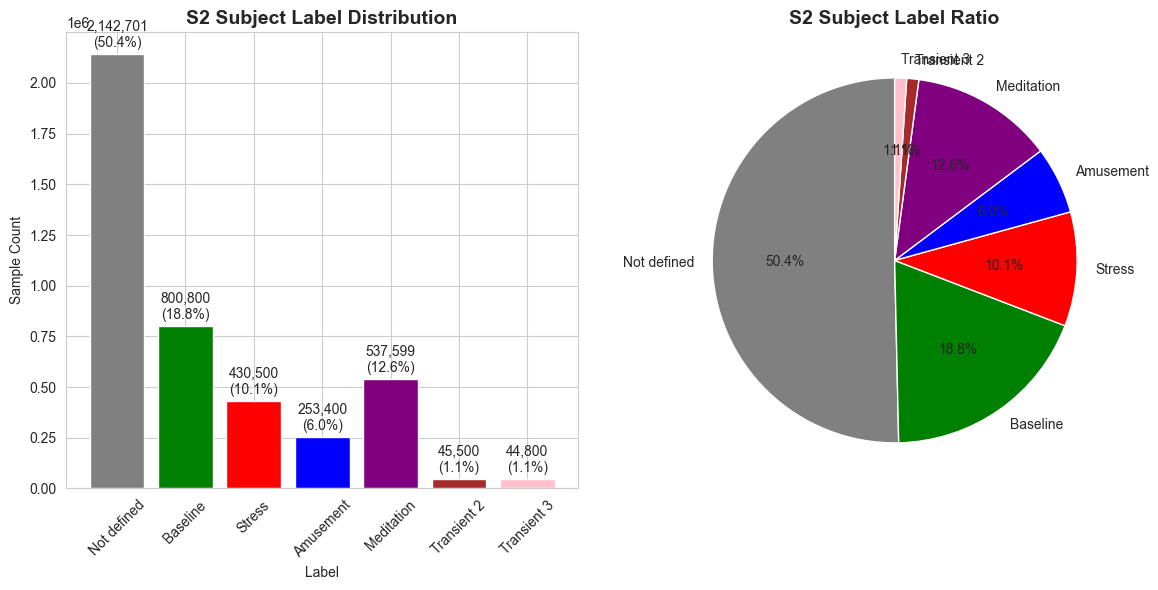


Total samples: 4,255,300
Not defined: 2,142,701 (50.35%)
Baseline: 800,800 (18.82%)
Stress: 430,500 (10.12%)
Amusement: 253,400 (5.95%)
Meditation: 537,599 (12.63%)
Transient 2: 45,500 (1.07%)
Transient 3: 44,800 (1.05%)


In [33]:
# Label distribution visualization
label_names = {
    0: 'Not defined', 
    1: 'Baseline', 
    2: 'Stress', 
    3: 'Amusement', 
    4: 'Meditation',
    5: 'Transient 1',
    6: 'Transient 2',
    7: 'Transient 3'
}
unique, counts = np.unique(labels, return_counts=True)

# Generate colors dynamically
color_map = {0: 'gray', 1: 'green', 2: 'red', 3: 'blue', 4: 'purple', 
             5: 'orange', 6: 'brown', 7: 'pink'}
colors = [color_map.get(i, 'lightgray') for i in unique]

plt.figure(figsize=(12, 6))

# Bar chart
plt.subplot(1, 2, 1)
bars = plt.bar([label_names.get(i, f'Unknown-{i}') for i in unique], counts, color=colors)
plt.title('S2 Subject Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Sample Count')
plt.xticks(rotation=45)
for i, (bar, count) in enumerate(zip(bars, counts)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01, 
             f'{count:,}\n({count/len(labels)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(counts, labels=[label_names.get(i, f'Unknown-{i}') for i in unique], autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('S2 Subject Label Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal samples: {len(labels):,}")
for label, count in zip(unique, counts):
    print(f"{label_names.get(label, f'Unknown-{label}')}: {count:,} ({count/len(labels)*100:.2f}%)")

## Experiment Timeline

Visualize the entire experiment timeline showing when each stimulus was applied.

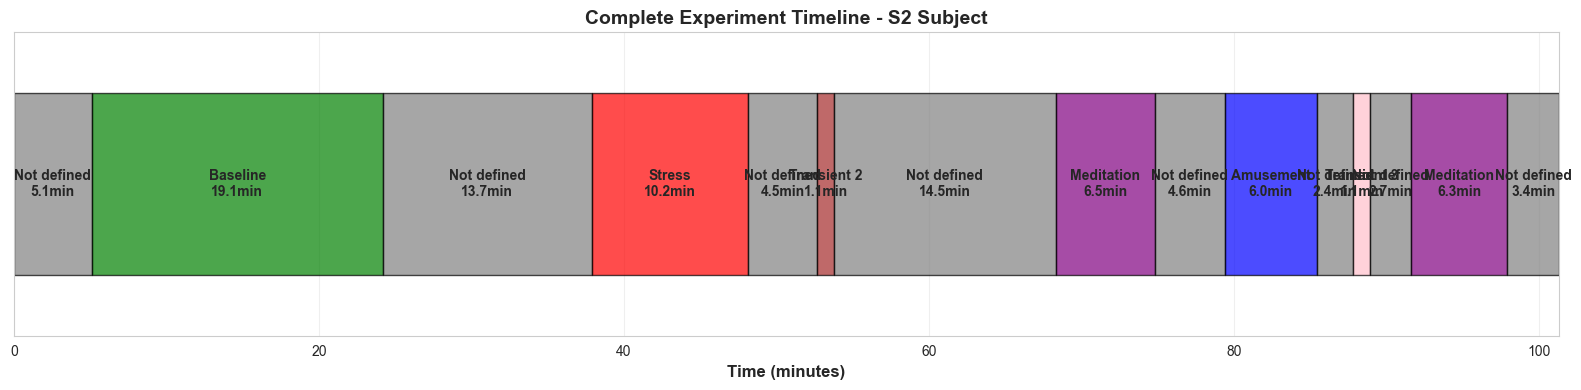


EXPERIMENT TIMELINE DETAILS
State           Start (min)     End (min)       Duration (min) 
--------------------------------------------------------------------------------
Not defined     0.00            5.11            5.11           
Baseline        5.11            24.18           19.07          
Not defined     24.18           37.89           13.72          
Stress          37.89           48.14           10.25          
Not defined     48.14           52.68           4.53           
Transient 2     52.68           53.76           1.08           
Not defined     53.76           68.29           14.53          
Meditation      68.29           74.81           6.52           
Not defined     74.81           79.39           4.58           
Amusement       79.39           85.43           6.03           
Not defined     85.43           87.83           2.40           
Transient 3     87.83           88.89           1.07           
Not defined     88.89           91.61           2.72      

In [34]:
# Create experiment timeline visualization
fig, ax = plt.subplots(figsize=(16, 4))

# Find state transitions and durations
current_label = labels[0]
start_idx_timeline = 0
segments = []

for i in range(1, len(labels)):
    if labels[i] != current_label:
        end_idx = i
        segments.append({
            'label': current_label,
            'start': start_idx_timeline / 700 / 60,  # Convert to minutes
            'end': end_idx / 700 / 60,
            'duration': (end_idx - start_idx_timeline) / 700 / 60
        })
        current_label = labels[i]
        start_idx_timeline = i

# Add last segment
segments.append({
    'label': current_label,
    'start': start_idx_timeline / 700 / 60,
    'end': len(labels) / 700 / 60,
    'duration': (len(labels) - start_idx_timeline) / 700 / 60
})

# Draw timeline
y_pos = 0.5
for seg in segments:
    color = color_map.get(seg['label'], 'lightgray')
    label_name = label_names.get(seg['label'], f"Unknown-{seg['label']}")
    
    ax.barh(y_pos, seg['duration'], left=seg['start'], height=0.6, 
            color=color, alpha=0.7, edgecolor='black', linewidth=1)
    
    # Add text label in the middle of each segment
    mid_point = seg['start'] + seg['duration'] / 2
    if seg['duration'] > 1:  # Only show text if segment is wide enough
        ax.text(mid_point, y_pos, f"{label_name}\n{seg['duration']:.1f}min", 
                ha='center', va='center', fontweight='bold', fontsize=10)

ax.set_ylim(0, 1)
ax.set_xlim(0, len(labels) / 700 / 60)
ax.set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
ax.set_yticks([])
ax.set_title('Complete Experiment Timeline - S2 Subject', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed timeline information
print("\n" + "=" * 80)
print("EXPERIMENT TIMELINE DETAILS")
print("=" * 80)
print(f"{'State':<15} {'Start (min)':<15} {'End (min)':<15} {'Duration (min)':<15}")
print("-" * 80)
for seg in segments:
    label_name = label_names.get(seg['label'], f"Unknown-{seg['label']}")
    print(f"{label_name:<15} {seg['start']:<15.2f} {seg['end']:<15.2f} {seg['duration']:<15.2f}")
print("=" * 80)
print(f"Total recording time: {len(labels) / 700 / 60:.2f} minutes ({len(labels) / 700 / 60 / 60:.2f} hours)")
print("=" * 80)

## Complete Chest Sensor Data with Stimulus Timeline

Visualize all chest sensor data across the entire experiment with color-coded stimulus periods.

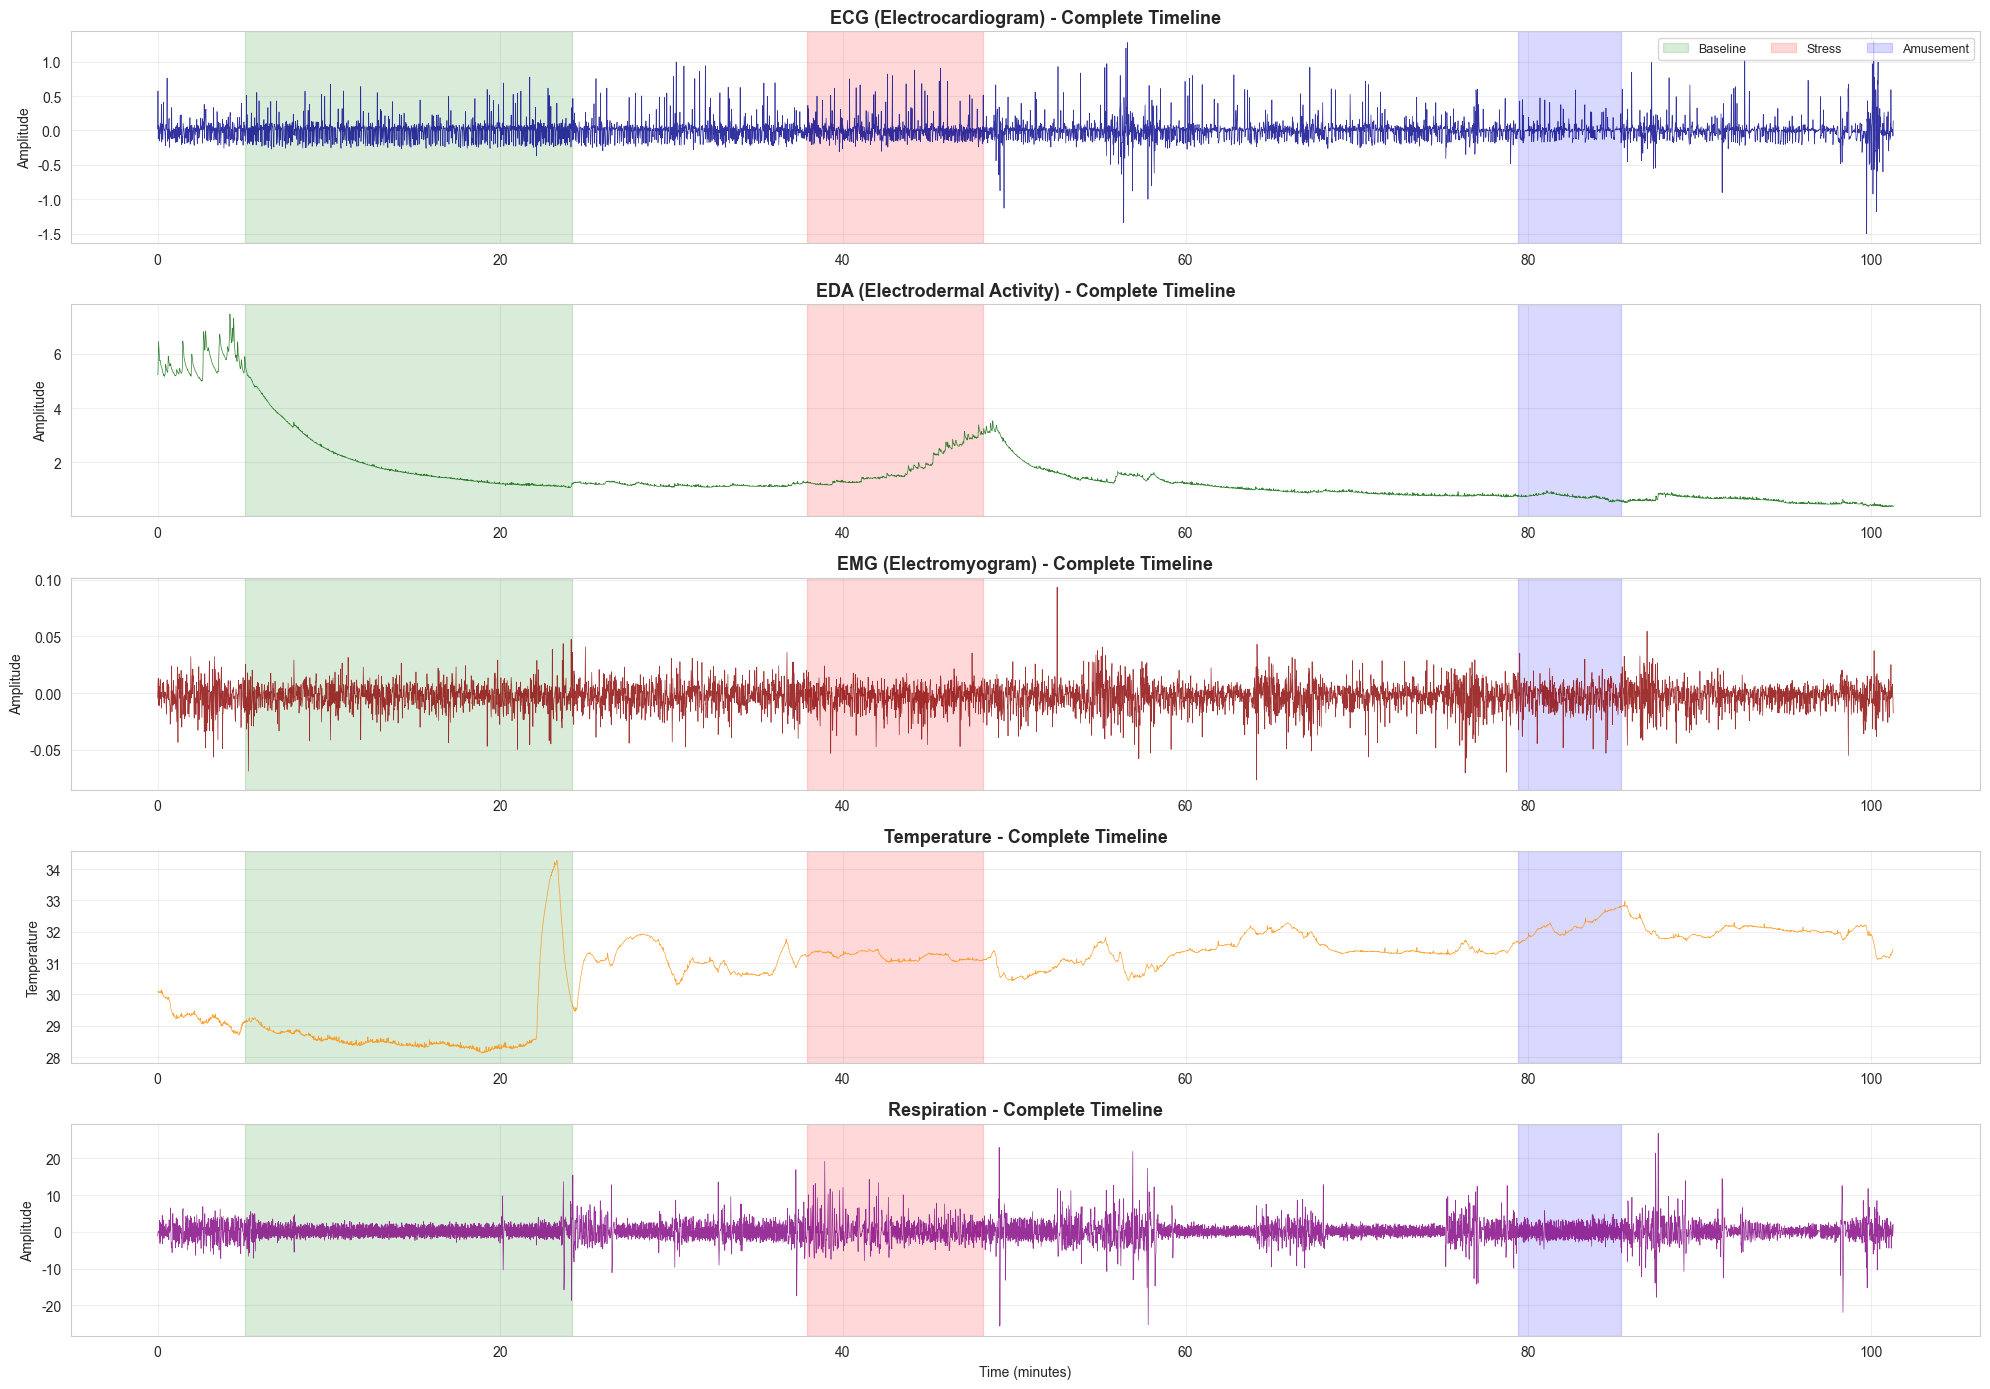


✓ Chest sensor data visualization complete (downsampled to 1Hz for clarity)

Color-coded periods show only main experimental conditions:
  🟢 Green = Baseline
  🔴 Red = Stress
  🔵 Blue = Amusement


In [43]:
# Visualize complete chest sensor data with stimulus timeline
# Downsample data for visualization (every 700 samples = 1 second intervals)
downsample_rate = 700  # Show 1 data point per second

# Downsample chest sensor data
chest_ecg_ds = chest['ECG'][::downsample_rate]
chest_eda_ds = chest['EDA'][::downsample_rate]
chest_emg_ds = chest['EMG'][::downsample_rate]
chest_temp_ds = chest['Temp'][::downsample_rate]
chest_resp_ds = chest['Resp'][::downsample_rate]
labels_ds = labels[::downsample_rate]

# Create time axis in minutes
time_minutes = np.arange(len(chest_ecg_ds)) / 60.0

# Function to add stimulus background colors
def add_stimulus_background(ax, labels_ds, time_minutes):
    """Add background colors for different stimulus periods (only Baseline, Stress, Amusement)"""
    # Only show these states: 1=Baseline, 2=Stress, 3=Amusement
    target_states = [1, 2, 3]
    
    current_label = labels_ds[0]
    start_time = 0
    
    for i in range(1, len(labels_ds)):
        if labels_ds[i] != current_label:
            end_time = time_minutes[i]
            # Only draw background for target states
            if current_label in target_states:
                color = color_map.get(current_label, 'lightgray')
                label_name = label_names.get(current_label, f'Unknown-{current_label}')
                ax.axvspan(start_time, end_time, alpha=0.15, color=color, label=label_name)
            current_label = labels_ds[i]
            start_time = end_time
    
    # Add last segment
    if current_label in target_states:
        color = color_map.get(current_label, 'lightgray')
        label_name = label_names.get(current_label, f'Unknown-{current_label}')
        ax.axvspan(start_time, time_minutes[-1], alpha=0.15, color=color, label=label_name)

# Create figure
fig, axes = plt.subplots(5, 1, figsize=(20, 14))

# ECG (Electrocardiogram)
add_stimulus_background(axes[0], labels_ds, time_minutes)
axes[0].plot(time_minutes, chest_ecg_ds, linewidth=0.5, color='darkblue', alpha=0.8)
axes[0].set_title('ECG (Electrocardiogram) - Complete Timeline', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
# Remove duplicate legend entries
handles, labels_legend = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
axes[0].legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9, ncol=4)

# EDA (Electrodermal Activity)
add_stimulus_background(axes[1], labels_ds, time_minutes)
axes[1].plot(time_minutes, chest_eda_ds, linewidth=0.5, color='darkgreen', alpha=0.8)
axes[1].set_title('EDA (Electrodermal Activity) - Complete Timeline', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

# EMG (Electromyogram)
add_stimulus_background(axes[2], labels_ds, time_minutes)
axes[2].plot(time_minutes, chest_emg_ds, linewidth=0.5, color='darkred', alpha=0.8)
axes[2].set_title('EMG (Electromyogram) - Complete Timeline', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)

# Temperature
add_stimulus_background(axes[3], labels_ds, time_minutes)
axes[3].plot(time_minutes, chest_temp_ds, linewidth=0.5, color='darkorange', alpha=0.8)
axes[3].set_title('Temperature - Complete Timeline', fontsize=13, fontweight='bold')
axes[3].set_ylabel('Temperature')
axes[3].grid(True, alpha=0.3)

# Respiration
add_stimulus_background(axes[4], labels_ds, time_minutes)
axes[4].plot(time_minutes, chest_resp_ds, linewidth=0.5, color='purple', alpha=0.8)
axes[4].set_title('Respiration - Complete Timeline', fontsize=13, fontweight='bold')
axes[4].set_ylabel('Amplitude')
axes[4].set_xlabel('Time (minutes)')
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Chest sensor data visualization complete (downsampled to 1Hz for clarity)")
print("\nColor-coded periods show only main experimental conditions:")
print("  🟢 Green = Baseline")
print("  🔴 Red = Stress") 
print("  🔵 Blue = Amusement")

## Complete Wrist Sensor Data with Stimulus Timeline

Visualize all wrist sensor (Empatica E4) data across the entire experiment with color-coded stimulus periods.

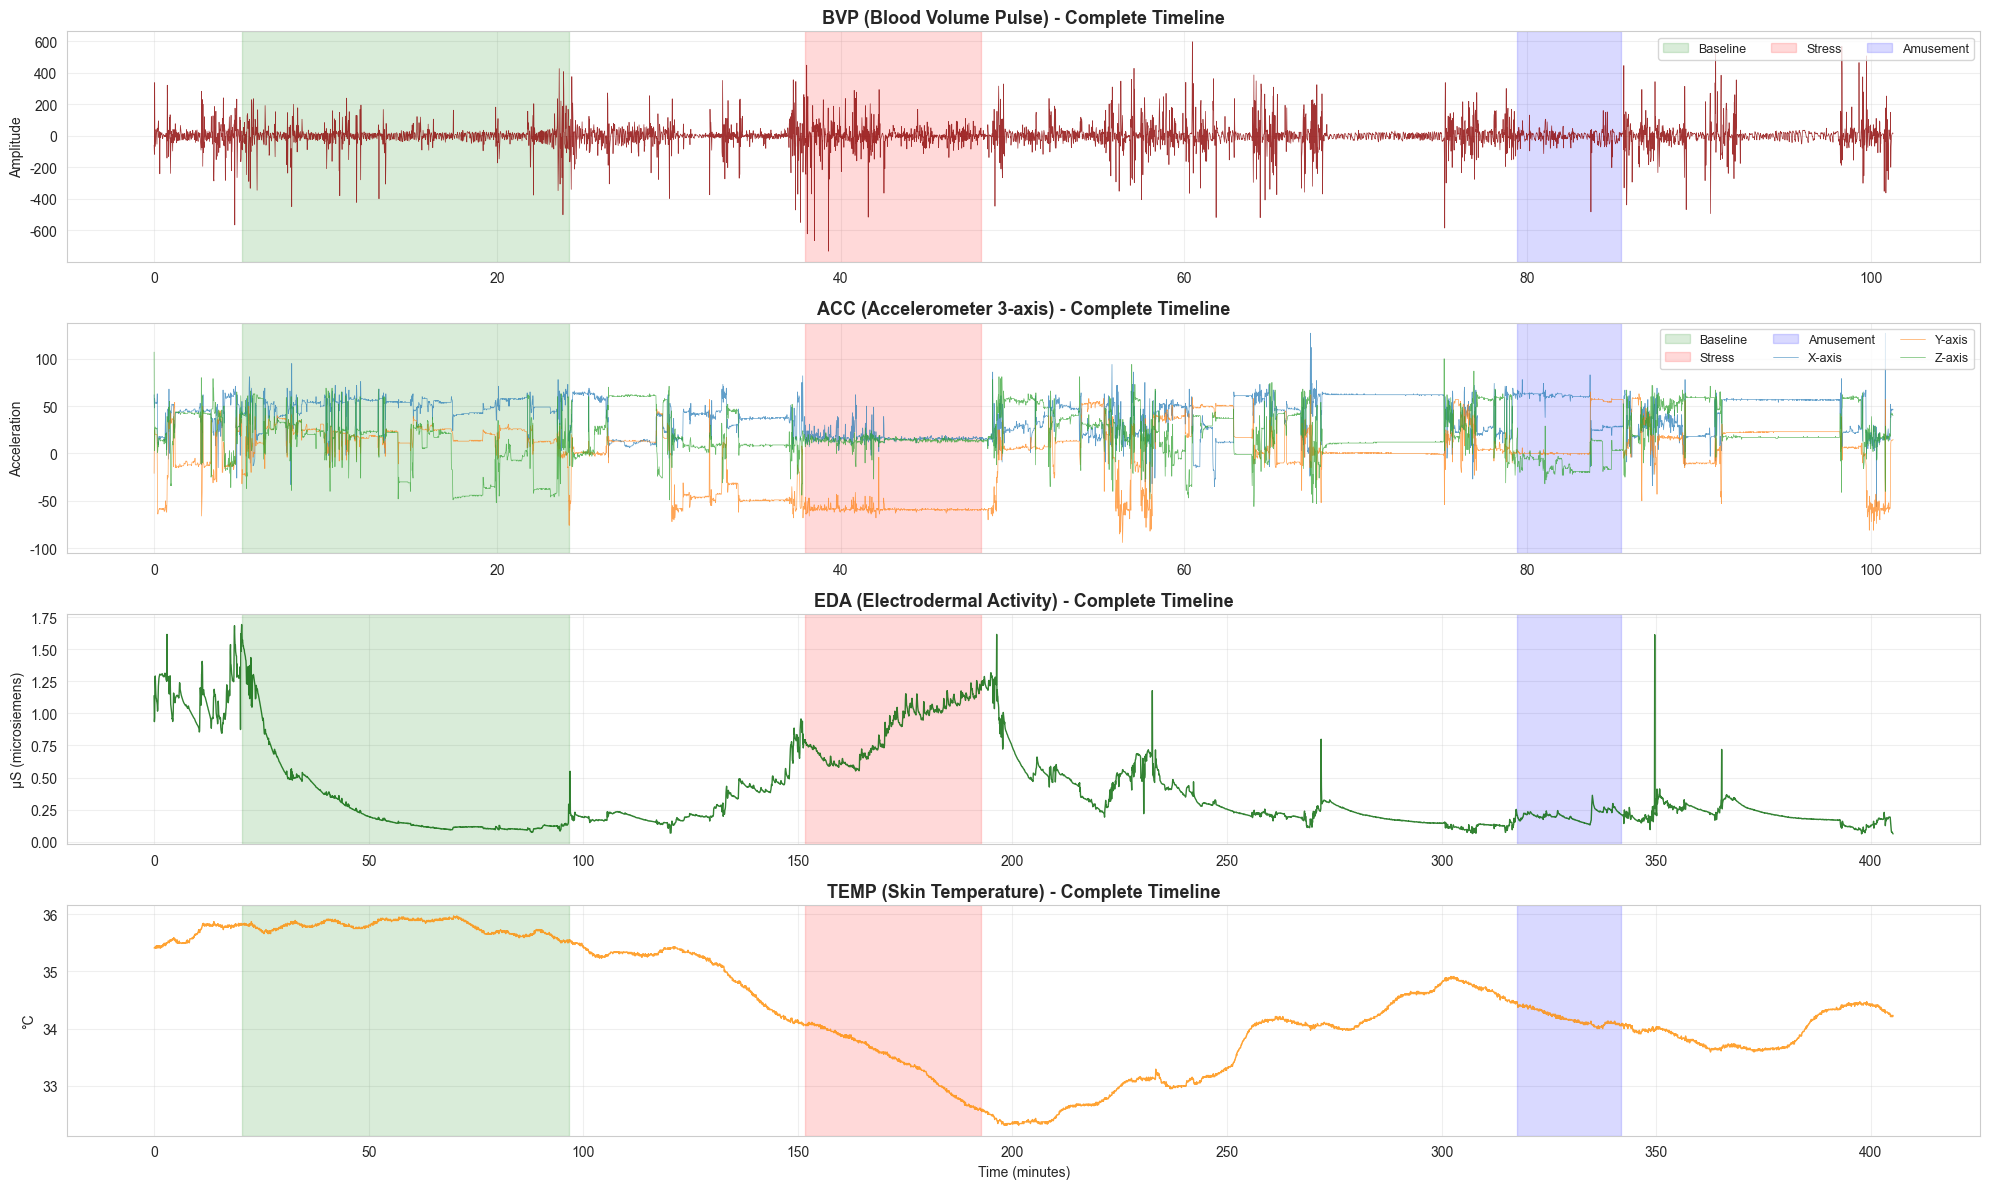


✓ Wrist sensor data visualization complete

Color-coded stimulus periods (only main experimental conditions):
  🟢 Green = Baseline (relaxed state)
  🔴 Red = Stress (stress test)
  🔵 Blue = Amusement (watching funny videos)

Note: Other periods (Not defined, Meditation, Transient) are not highlighted.


In [44]:
# Visualize complete wrist sensor data with stimulus timeline
# E4 sampling rates: BVP(64Hz), ACC(32Hz), EDA(4Hz), TEMP(4Hz)

# Downsample wrist sensor data (show 1 data point per second)
wrist_bvp_ds = wrist['BVP'][::64]  # 64Hz -> 1Hz
wrist_acc_ds = wrist['ACC'][::32]  # 32Hz -> 1Hz
wrist_eda_ds = wrist['EDA'][::4]   # 4Hz -> 0.25Hz (already low frequency)
wrist_temp_ds = wrist['TEMP'][::4] # 4Hz -> 0.25Hz (already low frequency)

# Create time axes for each sensor (in minutes)
time_bvp_min = np.arange(len(wrist_bvp_ds)) / 60.0
time_acc_min = np.arange(len(wrist_acc_ds)) / 60.0
time_eda_min = np.arange(len(wrist_eda_ds)) * 4 / 60.0  # 4 seconds per sample
time_temp_min = np.arange(len(wrist_temp_ds)) * 4 / 60.0  # 4 seconds per sample

# Use the same downsampled labels from chest sensor (already at 1Hz)
# Trim to match wrist sensor lengths
labels_wrist_bvp = labels_ds[:len(wrist_bvp_ds)]
labels_wrist_acc = labels_ds[:len(wrist_acc_ds)]
labels_wrist_eda = labels_ds[:len(wrist_eda_ds)]

# Create figure
fig, axes = plt.subplots(4, 1, figsize=(20, 12))

# BVP (Blood Volume Pulse)
add_stimulus_background(axes[0], labels_wrist_bvp, time_bvp_min)
axes[0].plot(time_bvp_min, wrist_bvp_ds, linewidth=0.5, color='darkred', alpha=0.8)
axes[0].set_title('BVP (Blood Volume Pulse) - Complete Timeline', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
handles, labels_legend = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
axes[0].legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9, ncol=4)

# ACC (Accelerometer) - 3 axes
add_stimulus_background(axes[1], labels_wrist_acc, time_acc_min)
axes[1].plot(time_acc_min, wrist_acc_ds[:, 0], label='X-axis', linewidth=0.5, alpha=0.7)
axes[1].plot(time_acc_min, wrist_acc_ds[:, 1], label='Y-axis', linewidth=0.5, alpha=0.7)
axes[1].plot(time_acc_min, wrist_acc_ds[:, 2], label='Z-axis', linewidth=0.5, alpha=0.7)
axes[1].set_title('ACC (Accelerometer 3-axis) - Complete Timeline', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Acceleration')
axes[1].legend(loc='upper right', fontsize=9, ncol=3)
axes[1].grid(True, alpha=0.3)

# EDA (Electrodermal Activity)
add_stimulus_background(axes[2], labels_wrist_eda, time_eda_min)
axes[2].plot(time_eda_min, wrist_eda_ds, linewidth=1, color='darkgreen', alpha=0.8)
axes[2].set_title('EDA (Electrodermal Activity) - Complete Timeline', fontsize=13, fontweight='bold')
axes[2].set_ylabel('μS (microsiemens)')
axes[2].grid(True, alpha=0.3)

# TEMP (Skin Temperature)
add_stimulus_background(axes[3], labels_wrist_eda, time_temp_min)
axes[3].plot(time_temp_min, wrist_temp_ds, linewidth=1, color='darkorange', alpha=0.8)
axes[3].set_title('TEMP (Skin Temperature) - Complete Timeline', fontsize=13, fontweight='bold')
axes[3].set_ylabel('°C')
axes[3].set_xlabel('Time (minutes)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Wrist sensor data visualization complete")
print("\nColor-coded stimulus periods (only main experimental conditions):")
print("  🟢 Green = Baseline (relaxed state)")
print("  🔴 Red = Stress (stress test)")
print("  🔵 Blue = Amusement (watching funny videos)")
print("\nNote: Other periods (Not defined, Meditation, Transient) are not highlighted.")

## Chest Sensor Data Visualization

Visualize physiological signals from the RespiBAN sensor attached to the chest.

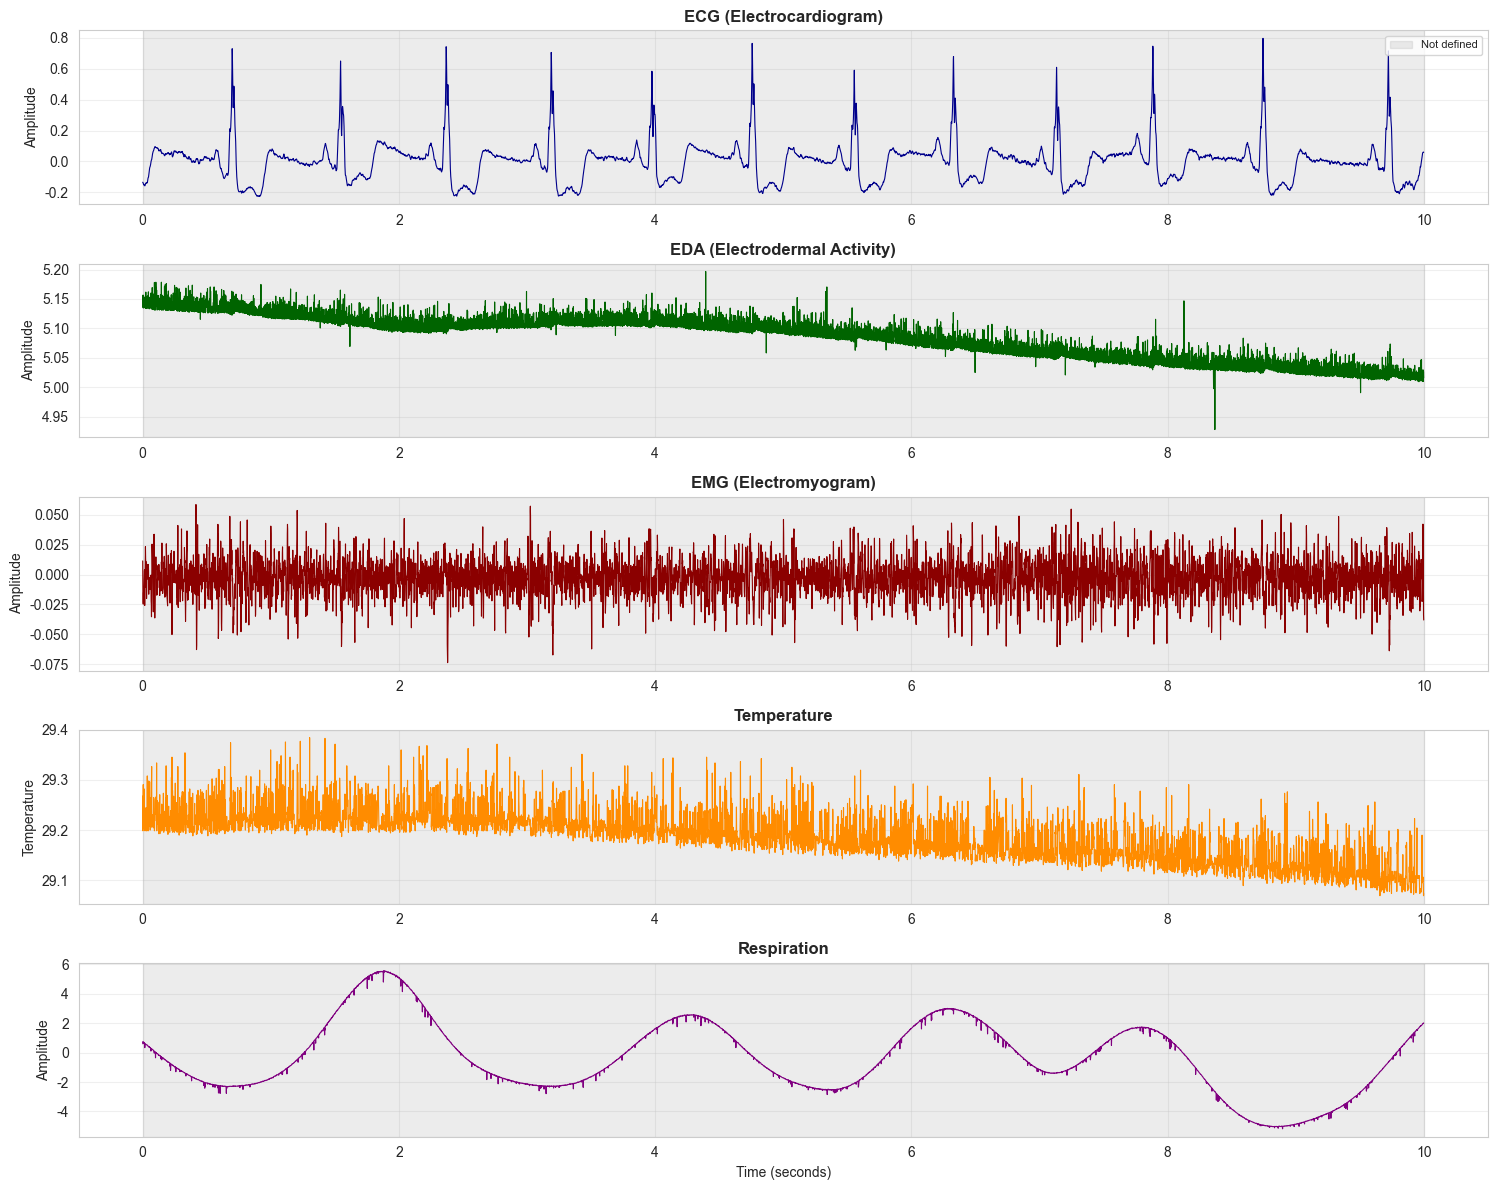


=== State Information for Displayed Segment ===
Time range: 142.9s - 152.9s
  Not defined: 10.00 seconds (100.0%)


In [37]:
# Chest sensor data visualization (partial sample)
# 700Hz sampling rate, 10 seconds (7000 samples)
start_idx = 100000  # Starting point
duration = 7000     # 10 seconds

# Create time axis (in seconds)
time = np.arange(duration) / 700.0

# Get labels for this time segment
segment_labels = labels[start_idx:start_idx+duration]

# Adjust ACC data if sampling rate is different
acc_data = chest['ACC'][start_idx:start_idx+duration]
if len(acc_data) < duration:
    acc_data = chest['ACC'][start_idx:start_idx+len(chest['ACC'])-start_idx]
    time_acc = np.arange(len(acc_data)) / 700.0
else:
    time_acc = time

fig, axes = plt.subplots(5, 1, figsize=(15, 12))

# Function to add state background colors
def add_state_background(ax, segment_labels, time):
    """Add background colors for different states"""
    state_colors = {
        0: ('gray', 'Not defined'),
        1: ('green', 'Baseline'),
        2: ('red', 'Stress'),
        3: ('blue', 'Amusement'),
        4: ('purple', 'Meditation')
    }
    
    # Find state transitions
    current_state = segment_labels[0]
    start_time = 0
    
    for i in range(1, len(segment_labels)):
        if segment_labels[i] != current_state:
            # Draw background for previous state
            end_time = time[i]
            if current_state in state_colors:
                color, name = state_colors[current_state]
                ax.axvspan(start_time, end_time, alpha=0.15, color=color, label=name)
            
            # Update to new state
            current_state = segment_labels[i]
            start_time = end_time
    
    # Draw last segment
    if current_state in state_colors:
        color, name = state_colors[current_state]
        ax.axvspan(start_time, time[-1], alpha=0.15, color=color, label=name)

# ECG (Electrocardiogram)
add_state_background(axes[0], segment_labels, time)
axes[0].plot(time, chest['ECG'][start_idx:start_idx+duration], linewidth=0.8, color='darkblue')
axes[0].set_title('ECG (Electrocardiogram)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=8)

# EDA (Electrodermal Activity)
add_state_background(axes[1], segment_labels, time)
axes[1].plot(time, chest['EDA'][start_idx:start_idx+duration], linewidth=0.8, color='darkgreen')
axes[1].set_title('EDA (Electrodermal Activity)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

# EMG (Electromyogram)
add_state_background(axes[2], segment_labels, time)
axes[2].plot(time, chest['EMG'][start_idx:start_idx+duration], linewidth=0.8, color='darkred')
axes[2].set_title('EMG (Electromyogram)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)

# Temperature
add_state_background(axes[3], segment_labels, time)
axes[3].plot(time, chest['Temp'][start_idx:start_idx+duration], linewidth=0.8, color='darkorange')
axes[3].set_title('Temperature', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Temperature')
axes[3].grid(True, alpha=0.3)

# Respiration
add_state_background(axes[4], segment_labels, time)
axes[4].plot(time, chest['Resp'][start_idx:start_idx+duration], linewidth=0.8, color='purple')
axes[4].set_title('Respiration', fontsize=12, fontweight='bold')
axes[4].set_ylabel('Amplitude')
axes[4].set_xlabel('Time (seconds)')
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print state information for this segment
print(f"\n=== State Information for Displayed Segment ===")
print(f"Time range: {start_idx/700:.1f}s - {(start_idx+duration)/700:.1f}s")
unique_segment, counts_segment = np.unique(segment_labels, return_counts=True)
for label, count in zip(unique_segment, counts_segment):
    duration_sec = count / 700
    print(f"  {label_names.get(label, f'Unknown-{label}')}: {duration_sec:.2f} seconds ({count/len(segment_labels)*100:.1f}%)")

## Wrist Sensor Data Visualization (E4)

Visualize physiological signals from the Empatica E4 wearable sensor attached to the wrist.

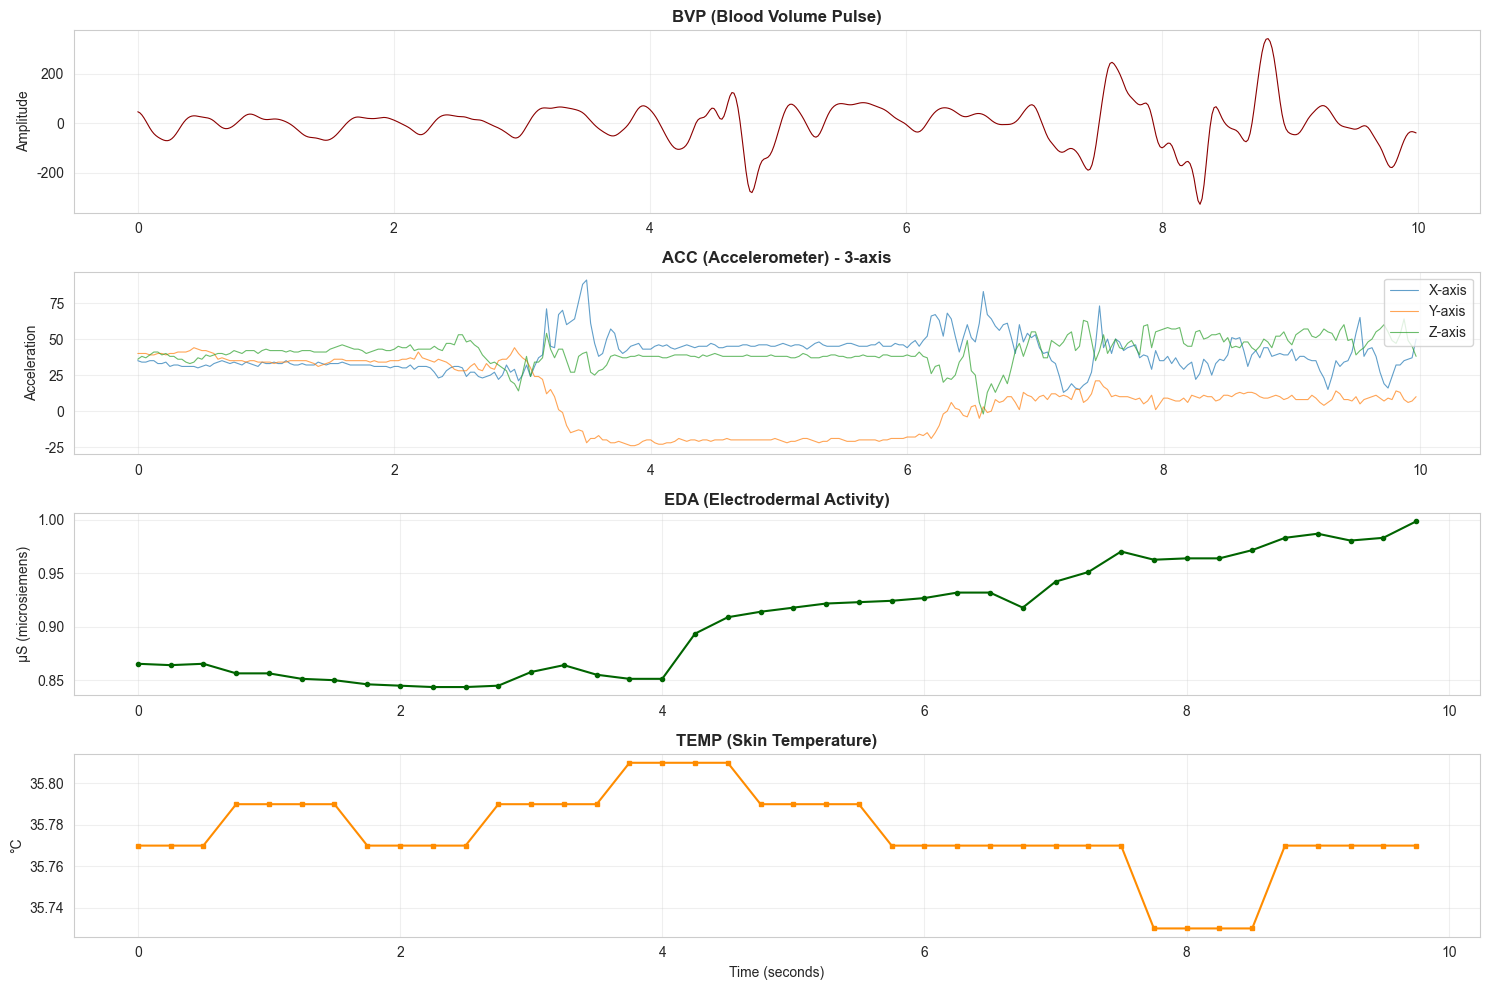

In [38]:
# Wrist sensor data visualization
# E4 sampling rates: BVP(64Hz), ACC(32Hz), EDA(4Hz), TEMP(4Hz)
start_idx_bvp = 15000  # BVP starting point
duration_bvp = 640     # 10 seconds (64Hz)

# Create time axis for each signal based on sampling rate
time_bvp = np.arange(duration_bvp) / 64.0
time_acc = np.arange(320) / 32.0  # 10 seconds (32Hz)
time_eda = np.arange(40) / 4.0    # 10 seconds (4Hz)
time_temp = np.arange(40) / 4.0   # 10 seconds (4Hz)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

# BVP (Blood Volume Pulse)
axes[0].plot(time_bvp, wrist['BVP'][start_idx_bvp:start_idx_bvp+duration_bvp], 
             linewidth=0.8, color='darkred')
axes[0].set_title('BVP (Blood Volume Pulse)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# ACC (Accelerometer) - 3 axes
start_idx_acc = start_idx_bvp // 2  # ACC is half the sampling rate of BVP
acc_x = wrist['ACC'][start_idx_acc:start_idx_acc+320, 0]
acc_y = wrist['ACC'][start_idx_acc:start_idx_acc+320, 1]
acc_z = wrist['ACC'][start_idx_acc:start_idx_acc+320, 2]
axes[1].plot(time_acc, acc_x, label='X-axis', linewidth=0.8, alpha=0.7)
axes[1].plot(time_acc, acc_y, label='Y-axis', linewidth=0.8, alpha=0.7)
axes[1].plot(time_acc, acc_z, label='Z-axis', linewidth=0.8, alpha=0.7)
axes[1].set_title('ACC (Accelerometer) - 3-axis', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Acceleration')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# EDA (Electrodermal Activity)
start_idx_eda = start_idx_bvp // 16  # EDA is 1/16 sampling rate of BVP
axes[2].plot(time_eda, wrist['EDA'][start_idx_eda:start_idx_eda+40], 
             linewidth=1.5, color='darkgreen', marker='o', markersize=3)
axes[2].set_title('EDA (Electrodermal Activity)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('μS (microsiemens)')
axes[2].grid(True, alpha=0.3)

# TEMP (Skin Temperature)
start_idx_temp = start_idx_bvp // 16  # TEMP is 1/16 sampling rate of BVP
axes[3].plot(time_temp, wrist['TEMP'][start_idx_temp:start_idx_temp+40], 
             linewidth=1.5, color='darkorange', marker='s', markersize=3)
axes[3].set_title('TEMP (Skin Temperature)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('°C')
axes[3].set_xlabel('Time (seconds)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Signal Comparison by State

Visualize differences in physiological signals according to each emotional state (Baseline, Stress, Amusement).

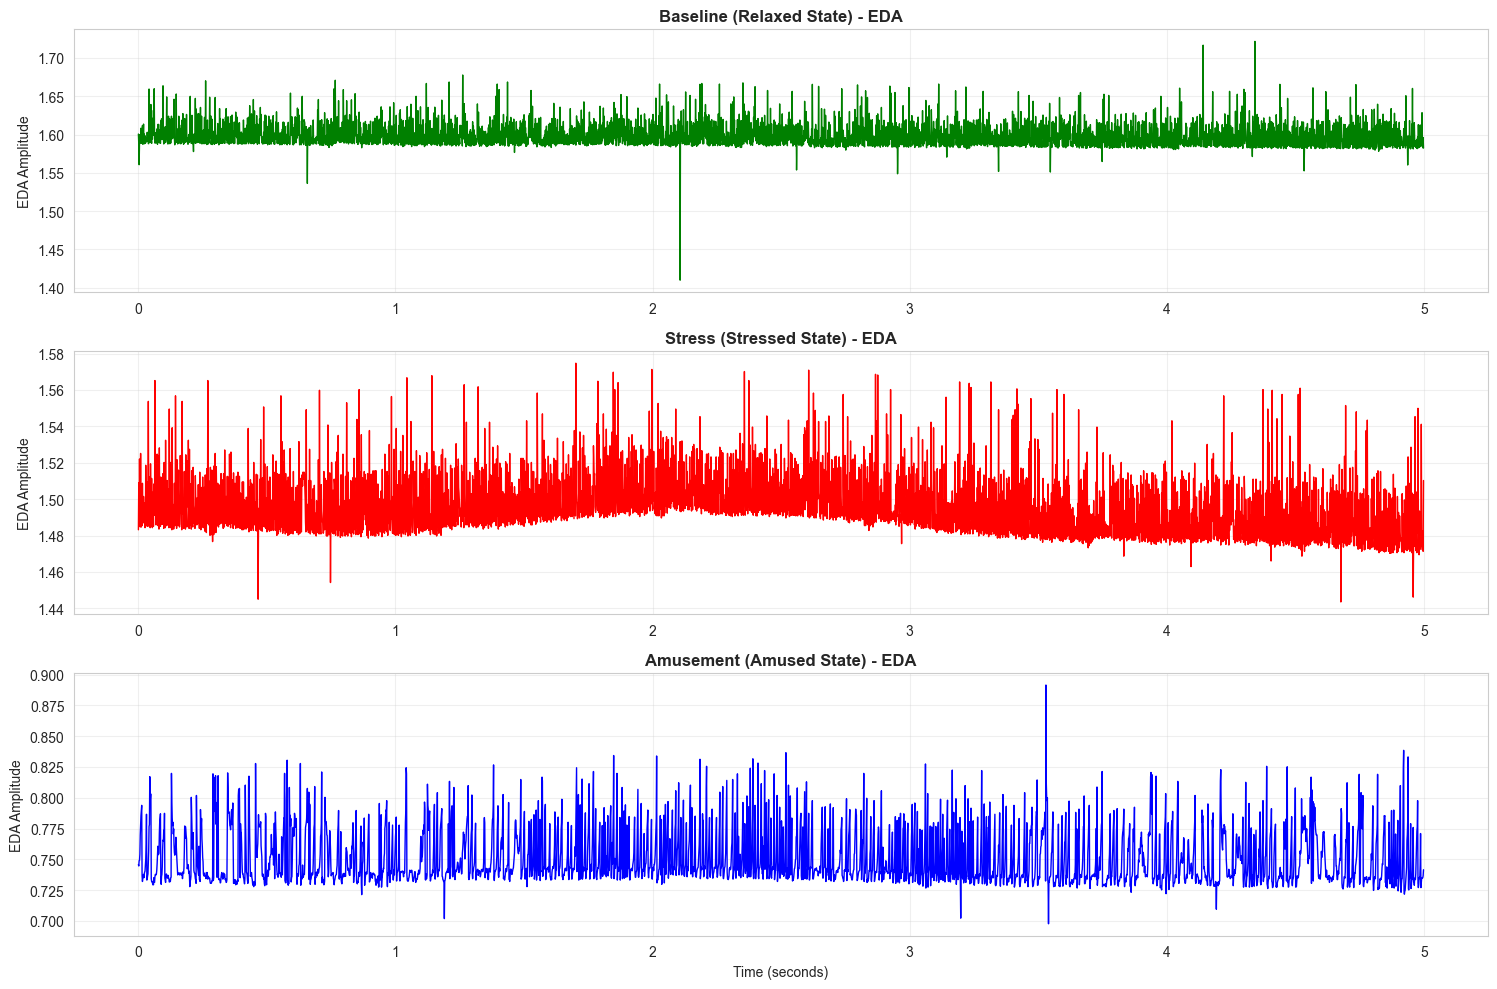

In [39]:
# Extract signals by state (Baseline, Stress, Amusement)
# Extract 5-second representative samples

def get_signal_segment(signal, label, target_label, duration=3500):
    """Extract signal segment for specific label (5 seconds at 700Hz)"""
    indices = np.where(label == target_label)[0]
    if len(indices) < duration:
        return None
    # Extract from middle portion
    start_idx = indices[len(indices)//2]
    return signal[start_idx:start_idx+duration]

# Time axis (5 seconds)
time_5s = np.arange(3500) / 700.0

# EDA signal comparison (Chest)
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Baseline
eda_baseline = get_signal_segment(chest['EDA'], labels, 1)
if eda_baseline is not None:
    axes[0].plot(time_5s, eda_baseline, color='green', linewidth=1)
    axes[0].set_title('Baseline (Relaxed State) - EDA', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('EDA Amplitude')
    axes[0].grid(True, alpha=0.3)

# Stress
eda_stress = get_signal_segment(chest['EDA'], labels, 2)
if eda_stress is not None:
    axes[1].plot(time_5s, eda_stress, color='red', linewidth=1)
    axes[1].set_title('Stress (Stressed State) - EDA', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('EDA Amplitude')
    axes[1].grid(True, alpha=0.3)

# Amusement
eda_amusement = get_signal_segment(chest['EDA'], labels, 3)
if eda_amusement is not None:
    axes[2].plot(time_5s, eda_amusement, color='blue', linewidth=1)
    axes[2].set_title('Amusement (Amused State) - EDA', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('EDA Amplitude')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Statistical Analysis by State

Compare statistical characteristics of physiological signals according to each emotional state.

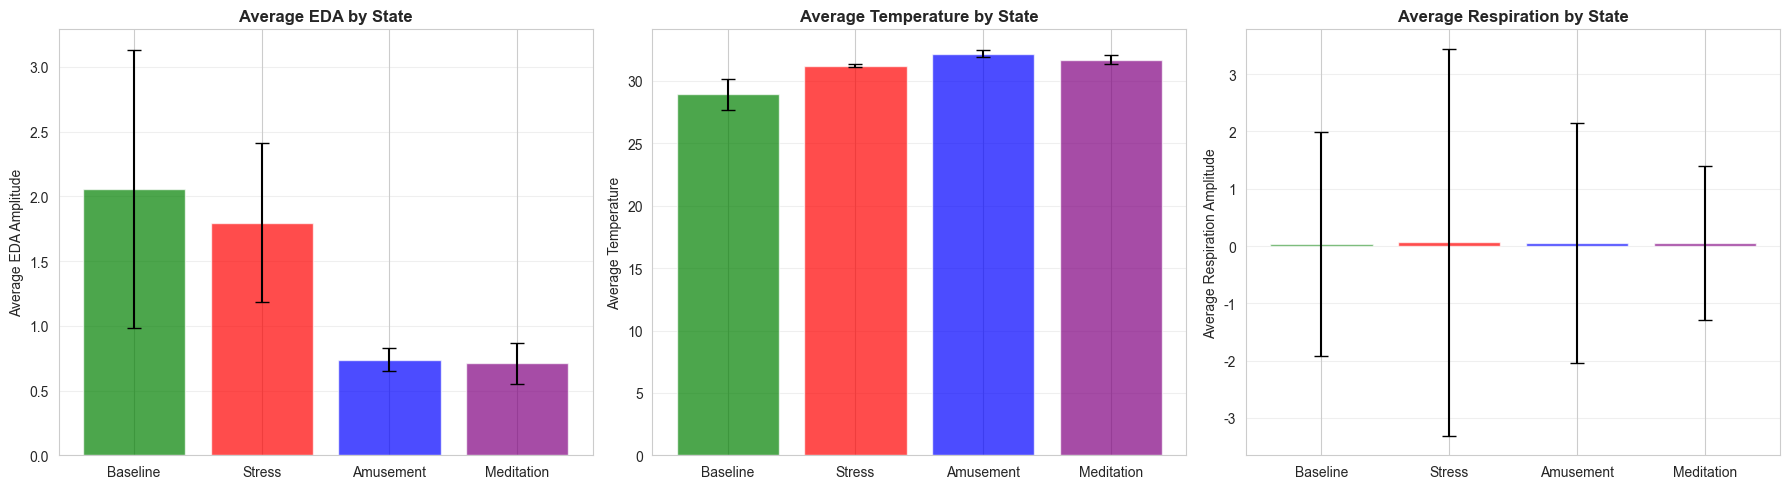


=== Physiological Signal Statistics by State ===

[Baseline]
  EDA - Mean: 2.0565, Std: 1.0755
  Temp - Mean: 28.9175, Std: 1.2684
  Resp - Mean: 0.0384, Std: 1.9500

[Stress]
  EDA - Mean: 1.7969, Std: 0.6136
  Temp - Mean: 31.2184, Std: 0.1209
  Resp - Mean: 0.0645, Std: 3.3790

[Amusement]
  EDA - Mean: 0.7372, Std: 0.0882
  Temp - Mean: 32.1948, Std: 0.3109
  Resp - Mean: 0.0488, Std: 2.0977

[Meditation]
  EDA - Mean: 0.7098, Std: 0.1584
  Temp - Mean: 31.7111, Std: 0.3668
  Resp - Mean: 0.0579, Std: 1.3461



In [40]:
# Compare EDA and Temperature averages by state
states = [1, 2, 3, 4]  # Baseline, Stress, Amusement, Meditation
state_names = ['Baseline', 'Stress', 'Amusement', 'Meditation']
colors_states = ['green', 'red', 'blue', 'purple']

# Chest EDA statistics
eda_stats = []
temp_stats = []
resp_stats = []

for state in states:
    indices = labels == state
    if np.sum(indices) > 0:
        eda_stats.append({
            'mean': np.mean(chest['EDA'][indices]),
            'std': np.std(chest['EDA'][indices]),
            'median': np.median(chest['EDA'][indices])
        })
        temp_stats.append({
            'mean': np.mean(chest['Temp'][indices]),
            'std': np.std(chest['Temp'][indices]),
            'median': np.median(chest['Temp'][indices])
        })
        resp_stats.append({
            'mean': np.mean(chest['Resp'][indices]),
            'std': np.std(chest['Resp'][indices]),
            'median': np.median(chest['Resp'][indices])
        })
    else:
        eda_stats.append({'mean': 0, 'std': 0, 'median': 0})
        temp_stats.append({'mean': 0, 'std': 0, 'median': 0})
        resp_stats.append({'mean': 0, 'std': 0, 'median': 0})

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# EDA average comparison
eda_means = [s['mean'] for s in eda_stats]
eda_stds = [s['std'] for s in eda_stats]
axes[0].bar(state_names, eda_means, yerr=eda_stds, color=colors_states, alpha=0.7, capsize=5)
axes[0].set_title('Average EDA by State', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average EDA Amplitude')
axes[0].grid(True, alpha=0.3, axis='y')

# Temperature average comparison
temp_means = [s['mean'] for s in temp_stats]
temp_stds = [s['std'] for s in temp_stats]
axes[1].bar(state_names, temp_means, yerr=temp_stds, color=colors_states, alpha=0.7, capsize=5)
axes[1].set_title('Average Temperature by State', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Temperature')
axes[1].grid(True, alpha=0.3, axis='y')

# Respiration average comparison
resp_means = [s['mean'] for s in resp_stats]
resp_stds = [s['std'] for s in resp_stats]
axes[2].bar(state_names, resp_means, yerr=resp_stds, color=colors_states, alpha=0.7, capsize=5)
axes[2].set_title('Average Respiration by State', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Respiration Amplitude')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics table
print("\n=== Physiological Signal Statistics by State ===\n")
for i, state_name in enumerate(state_names):
    print(f"[{state_name}]")
    print(f"  EDA - Mean: {eda_stats[i]['mean']:.4f}, Std: {eda_stats[i]['std']:.4f}")
    print(f"  Temp - Mean: {temp_stats[i]['mean']:.4f}, Std: {temp_stats[i]['std']:.4f}")
    print(f"  Resp - Mean: {resp_stats[i]['mean']:.4f}, Std: {resp_stats[i]['std']:.4f}")
    print()

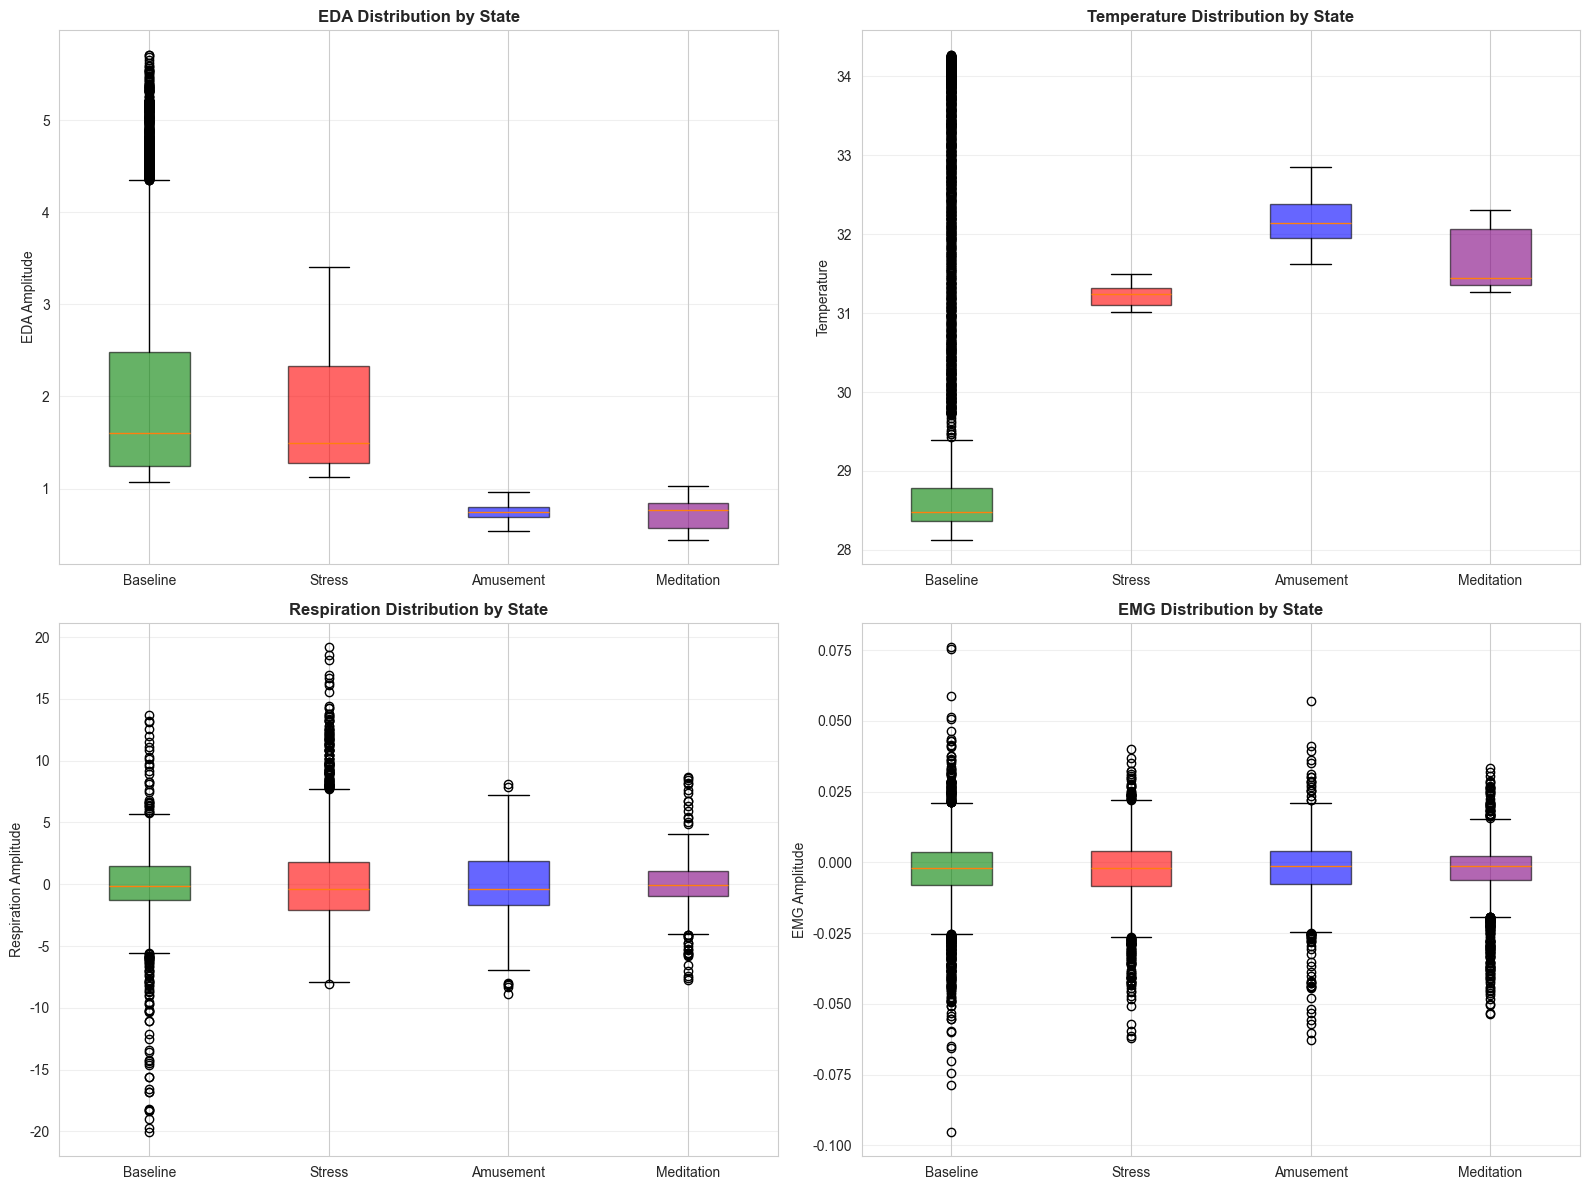

In [41]:
# Compare signal distribution by state with box plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data (sample for visualization - full data is too large)
sample_rate = 100  # Sample 1 out of every 100

# EDA distribution
eda_data = []
for state in states:
    indices = labels == state
    if np.sum(indices) > 0:
        eda_samples = chest['EDA'][indices][::sample_rate].flatten()
        if len(eda_samples) > 0:
            eda_data.append(eda_samples)
        else:
            eda_data.append(np.array([0]))
    else:
        eda_data.append(np.array([0]))

bp1 = axes[0, 0].boxplot(eda_data, tick_labels=state_names, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_states):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 0].set_title('EDA Distribution by State', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('EDA Amplitude')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Temperature distribution
temp_data = []
for state in states:
    indices = labels == state
    if np.sum(indices) > 0:
        temp_samples = chest['Temp'][indices][::sample_rate].flatten()
        if len(temp_samples) > 0:
            temp_data.append(temp_samples)
        else:
            temp_data.append(np.array([0]))
    else:
        temp_data.append(np.array([0]))

bp2 = axes[0, 1].boxplot(temp_data, tick_labels=state_names, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_states):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0, 1].set_title('Temperature Distribution by State', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Temperature')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Respiration distribution
resp_data = []
for state in states:
    indices = labels == state
    if np.sum(indices) > 0:
        resp_samples = chest['Resp'][indices][::sample_rate].flatten()
        if len(resp_samples) > 0:
            resp_data.append(resp_samples)
        else:
            resp_data.append(np.array([0]))
    else:
        resp_data.append(np.array([0]))

bp3 = axes[1, 0].boxplot(resp_data, tick_labels=state_names, patch_artist=True)
for patch, color in zip(bp3['boxes'], colors_states):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 0].set_title('Respiration Distribution by State', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Respiration Amplitude')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# EMG distribution
emg_data = []
for state in states:
    indices = labels == state
    if np.sum(indices) > 0:
        emg_samples = chest['EMG'][indices][::sample_rate].flatten()
        if len(emg_samples) > 0:
            emg_data.append(emg_samples)
        else:
            emg_data.append(np.array([0]))
    else:
        emg_data.append(np.array([0]))

bp4 = axes[1, 1].boxplot(emg_data, tick_labels=state_names, patch_artist=True)
for patch, color in zip(bp4['boxes'], colors_states):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 1].set_title('EMG Distribution by State', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('EMG Amplitude')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Data Summary

Overall summary information of subject S2 data.

In [42]:
# S2 Subject Data Summary
print("=" * 70)
print("S2 Subject Data Summary")
print("=" * 70)

print("\n[Basic Information]")
print(f"  Age: 27 years")
print(f"  Gender: Male")
print(f"  Height: 175cm")
print(f"  Weight: 80kg")

print("\n[Data Structure]")
print(f"  Total samples: {len(labels):,}")
print(f"  Total recording time: {len(labels)/700/60:.1f} min (700Hz basis)")

print("\n[Chest Sensor (RespiBAN)]")
print(f"  Sampling rate: 700Hz")
print(f"  Sensor types: ECG, EDA, EMG, Temp, Resp, ACC")
for key in ['ECG', 'EDA', 'EMG', 'Temp', 'Resp']:
    print(f"    - {key}: {chest[key].shape}")

print("\n[Wrist Sensor (Empatica E4)]")
print(f"  Sensor types: BVP(64Hz), ACC(32Hz), EDA(4Hz), TEMP(4Hz)")
print(f"    - BVP: {wrist['BVP'].shape}")
print(f"    - ACC: {wrist['ACC'].shape}")
print(f"    - EDA: {wrist['EDA'].shape}")
print(f"    - TEMP: {wrist['TEMP'].shape}")

print("\n[Label Distribution]")
for label, count in zip(unique, counts):
    duration_minutes = count / 700 / 60
    print(f"  {label_names.get(label, f'Unknown-{label}')}: {count:,} samples ({count/len(labels)*100:.1f}%, {duration_minutes:.1f} min)")

print("\n" + "=" * 70)

S2 Subject Data Summary

[Basic Information]
  Age: 27 years
  Gender: Male
  Height: 175cm
  Weight: 80kg

[Data Structure]
  Total samples: 4,255,300
  Total recording time: 101.3 min (700Hz basis)

[Chest Sensor (RespiBAN)]
  Sampling rate: 700Hz
  Sensor types: ECG, EDA, EMG, Temp, Resp, ACC
    - ECG: (4255300, 1)
    - EDA: (4255300, 1)
    - EMG: (4255300, 1)
    - Temp: (4255300, 1)
    - Resp: (4255300, 1)

[Wrist Sensor (Empatica E4)]
  Sensor types: BVP(64Hz), ACC(32Hz), EDA(4Hz), TEMP(4Hz)
    - BVP: (389056, 1)
    - ACC: (194528, 3)
    - EDA: (24316, 1)
    - TEMP: (24316, 1)

[Label Distribution]
  Not defined: 2,142,701 samples (50.4%, 51.0 min)
  Baseline: 800,800 samples (18.8%, 19.1 min)
  Stress: 430,500 samples (10.1%, 10.2 min)
  Amusement: 253,400 samples (6.0%, 6.0 min)
  Meditation: 537,599 samples (12.6%, 12.8 min)
  Transient 2: 45,500 samples (1.1%, 1.1 min)
  Transient 3: 44,800 samples (1.1%, 1.1 min)

